# 01 — Data Exploration

**Interpretable Speech Emotion Recognition (SER)**

This notebook loads the **RAVDESS** speech-emotion dataset, decodes the labels
that are embedded in each filename, and explores the data before any modelling.

> **Context.** My research background is in SER on *authentic* emotional speech
> (real 911 emergency-call audio, with SHAP-based interpretability). Because that
> corpus is lab-controlled, this public project reproduces the same methodology on
> **RAVDESS** — a widely-used, openly-licensed corpus of *acted* emotional speech —
> which lets anyone download and run the full pipeline. A recurring theme of the
> project is the gap between *acted* and *authentic* emotion.

**RAVDESS:** 24 actors × 60 clips = 1,440 WAV files, 8 emotions. The emotion is
encoded in the filename (e.g. `03-01-06-01-02-01-12.wav` → position 3 = `06` = *fearful*).

In [1]:
import os, glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa, librosa.display
import soundfile as sf

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)

DATA_DIR = os.path.join("data", "ravdess")
FIG_DIR = "figures"
os.makedirs(FIG_DIR, exist_ok=True)
print("data dir exists:", os.path.isdir(DATA_DIR))

data dir exists: True


## 1. Load the file list and decode the filenames

Each RAVDESS filename is a 7-part numeric code. We only need a few parts:
position **3** = emotion, position **4** = intensity, position **7** = actor
(odd = male, even = female).

In [2]:
EMOTION = {"01": "neutral", "02": "calm", "03": "happy", "04": "sad",
           "05": "angry", "06": "fearful", "07": "disgust", "08": "surprised"}
INTENSITY = {"01": "normal", "02": "strong"}

rows = []
for path in sorted(glob.glob(os.path.join(DATA_DIR, "Actor_*", "*.wav"))):
    parts = os.path.splitext(os.path.basename(path))[0].split("-")
    actor = int(parts[6])
    rows.append({
        "path": path,
        "emotion": EMOTION[parts[2]],
        "intensity": INTENSITY[parts[3]],
        "actor": actor,
        "gender": "male" if actor % 2 == 1 else "female",
    })

df = pd.DataFrame(rows)
print(f"{len(df)} clips  |  {df.actor.nunique()} actors  |  {df.emotion.nunique()} emotions")
df.head()

1440 clips  |  24 actors  |  8 emotions


,path,emotion,intensity,actor,gender
0,data\ravdess\Actor_01\03-01-01-01-01-01-01.wav,neutral,normal,1,male
1,data\ravdess\Actor_01\03-01-01-01-01-02-01.wav,neutral,normal,1,male
2,data\ravdess\Actor_01\03-01-01-01-02-01-01.wav,neutral,normal,1,male
3,data\ravdess\Actor_01\03-01-01-01-02-02-01.wav,neutral,normal,1,male
4,data\ravdess\Actor_01\03-01-02-01-01-01-01.wav,calm,normal,1,male


## 2. Class distribution

RAVDESS is well balanced across emotions, with one expected exception: **neutral**
has half as many clips, because it is only recorded at *normal* intensity (there is
no "strong neutral").

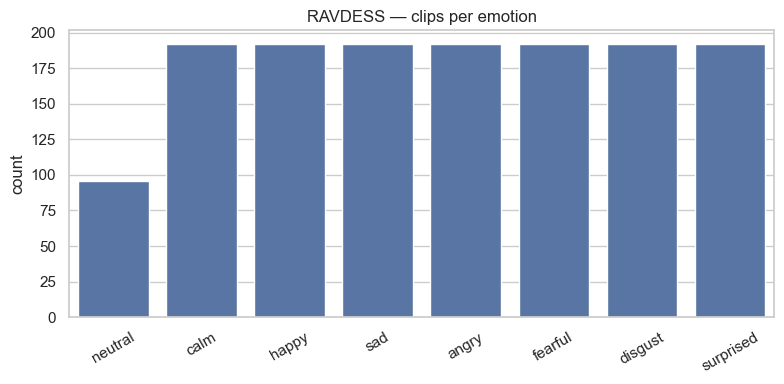

emotion
neutral       96
calm         192
happy        192
sad          192
angry        192
fearful      192
disgust      192
surprised    192
Name: count, dtype: int64

In [3]:
ORDER = ["neutral", "calm", "happy", "sad", "angry", "fearful", "disgust", "surprised"]

plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="emotion", order=ORDER, color="#4C72B0")
ax.set_title("RAVDESS — clips per emotion")
ax.set(xlabel="", ylabel="count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_emotion_distribution.png"), dpi=120)
plt.show()

df["emotion"].value_counts().reindex(ORDER)

## 3. Gender balance

The corpus is gender-balanced (12 male, 12 female actors) — important, because
acoustic features such as pitch differ systematically between speakers.

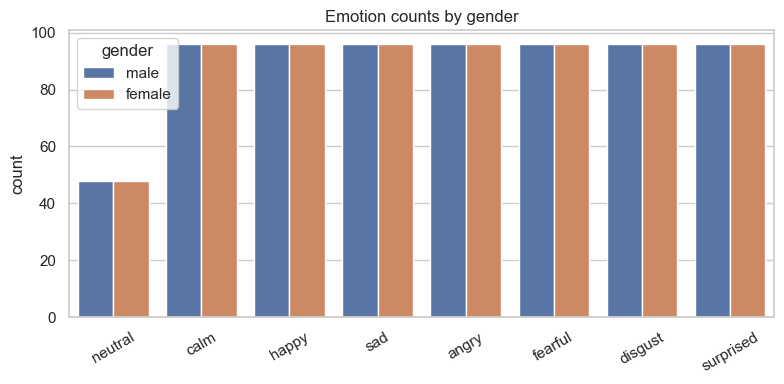

In [4]:
plt.figure(figsize=(8, 4))
ax = sns.countplot(data=df, x="emotion", hue="gender", order=ORDER)
ax.set_title("Emotion counts by gender")
ax.set(xlabel="", ylabel="count")
plt.xticks(rotation=30)
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_emotion_by_gender.png"), dpi=120)
plt.show()

## 4. Clip duration

We read each file's duration from its header (fast — no decoding). RAVDESS clips
are short single-sentence utterances, typically 3–5 seconds.

count    1440.00
mean        3.70
std         0.34
min         2.94
25%         3.47
50%         3.67
75%         3.87
max         5.27
Name: duration_sec, dtype: float64


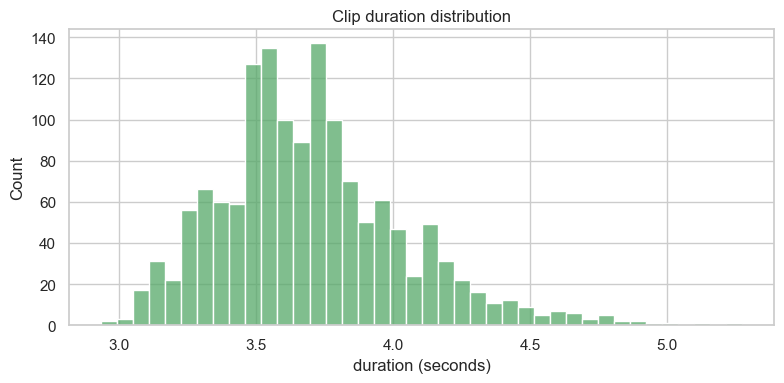

In [5]:
df["duration_sec"] = df["path"].apply(lambda p: sf.info(p).duration)
print(df["duration_sec"].describe().round(2))

plt.figure(figsize=(8, 4))
sns.histplot(df["duration_sec"], bins=40, color="#55A868")
plt.title("Clip duration distribution")
plt.xlabel("duration (seconds)")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_duration_hist.png"), dpi=120)
plt.show()

## 5. A closer look at one clip — waveform & mel-spectrogram

The **waveform** shows amplitude (loudness) over time; the **mel-spectrogram** shows
how energy is distributed across frequency over time — this is the visual the
feature-extraction step (next notebook) turns into numbers.

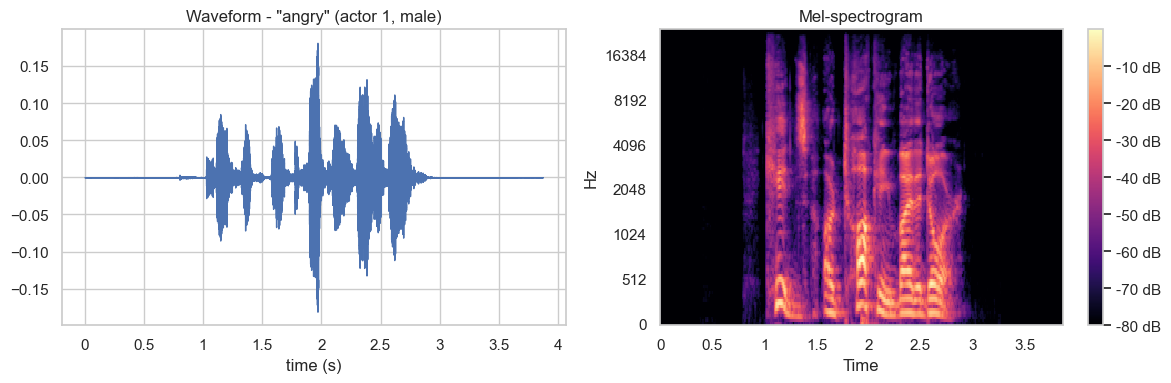

In [6]:
sample = df[df.emotion == "angry"].iloc[0]
y, sr = librosa.load(sample["path"], sr=None)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
librosa.display.waveshow(y, sr=sr, ax=axes[0])
axes[0].set_title(f'Waveform - "{sample.emotion}" (actor {sample.actor}, {sample.gender})')
axes[0].set_xlabel("time (s)")

S = librosa.feature.melspectrogram(y=y, sr=sr, n_mels=128)
S_db = librosa.power_to_db(S, ref=np.max)
img = librosa.display.specshow(S_db, sr=sr, x_axis="time", y_axis="mel", ax=axes[1])
axes[1].set_title("Mel-spectrogram")
fig.colorbar(img, ax=axes[1], format="%+2.0f dB")
plt.tight_layout()
plt.savefig(os.path.join(FIG_DIR, "01_sample_waveform_spectrogram.png"), dpi=120)
plt.show()

## Takeaways

- **1,440 clips**, balanced across 8 emotions and 2 genders (neutral is the one
  smaller class, by design).
- Clips are short (~3–5 s) single-sentence utterances → **no segmentation needed**
  (unlike spontaneous 911 speech, where intonation-unit segmentation was required).
- Next: **`02_feature_extraction`** — turn each clip into ~acoustic-prosodic features
  (intensity, pitch, MFCCs, spectral, …) using `librosa`.